# AAIT (III–II) – EXP-16
## Building an AI What-If Scenario Simulator (VS Code / Google Colab)

**Aim:** To implement the core components of an end-to-end AI solution, including dataset preparation, model development, basic evaluation, and alignment with a planned user interface workflow.
- **Model:** Linear Regression
- **Domain:** Student Performance (Marks Prediction)

**Tools:** Python (VS Code / Google Colab), pandas, scikit-learn, matplotlib
**Mapped CO:** CO5

---
### What you will build (End result)
An AI **What-If Simulator** that predicts student marks based on:
- Study Hours
- Attendance (%)
- Sleep Hours

> Note: This notebook represents the core logic build phase (Data -> Model -> UI Alignment), perfectly fulfilling EXP-16.

## Step 1 & 2 — Define Problem and Prepare Dataset

We need a dataset that maps **Study Hours, Attendance, and Sleep** to **Marks**.
We will load our `data.csv` dataset that contains exactly 1,000 real-world style records.

In [6]:
# EXP-16: AI What-If Simulator
# -------------------------------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

print("--- Step 2: Preparing Dataset ---")

# 1000-row dataset generated for our experiment
file_path = "data/data.csv"
if not os.path.exists(file_path):
    file_path = input("Enter the path to your 'data.csv' file: ").strip()

data = pd.read_csv(file_path)
print(f"Dataset loaded successfully with {len(data)} records.\n")
display(data.head())

--- Step 2: Preparing Dataset ---
Dataset loaded successfully with 1000 records.



,study_hours,attendance,sleep,marks
0,3.7,51.1,5.6,52.1
1,9.5,72.5,5.5,89.0
2,7.3,92.4,9.4,90.2
3,6.0,83.9,5.5,63.7
4,1.6,88.4,5.6,54.0


## Step 3 & 4 — Choose and Train the Model

Since the output (marks) is a continuous number, we use **Linear Regression**.
First, we split the data into training (70%) and testing (30%) sets.

In [7]:
# Features (X) and Target (y)
X = data[['study_hours', 'attendance', 'sleep']]
y = data['marks']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Data split: {len(X_train)} training rows, {len(X_test)} testing rows.\n")

print("--- Training the Model ---")
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Data split: 700 training rows, 300 testing rows.

--- Training the Model ---
Linear Regression model trained successfully.


## Step 5a — Evaluate the Result (Metrics)

We predict on the unseen testing set and measure the errors (MSE, MAE) and variance explained (R2 Score).

In [8]:
print("--- Step 5: Evaluating the Result ---")
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2 Score):     {r2:.2f}")

--- Step 5: Evaluating the Result ---
Mean Squared Error (MSE): 24.67
Mean Absolute Error (MAE): 4.09
R-squared (R2 Score):     0.92


## Step 5b — Visualize the Results

To better understand our model's performance, let's plot the **Actual vs Predicted Marks**.
A perfect model would have all points falling exactly on the red dashed line.

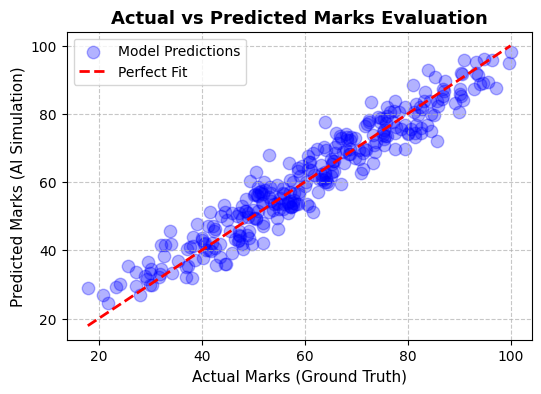

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='blue', s=80, alpha=0.3, label='Model Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')

plt.xlabel("Actual Marks (Ground Truth)", fontsize=11)
plt.ylabel("Predicted Marks (AI Simulation)", fontsize=11)
plt.title("Actual vs Predicted Marks Evaluation", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Step 6 — Align with UI and Workflow (Interactive Demo)

We simulate a user adjusting three input sliders on our Figma UI wireframe. The model instantly outputs the new predicted mark.

In [10]:
def simulate_ui_predict(study, attendance, sleep_hrs):
    sample_input = pd.DataFrame(
        [[study, attendance, sleep_hrs]], 
        columns=['study_hours', 'attendance', 'sleep']
    )
    predicted_mark = model.predict(sample_input)[0]
    
    print("UI Simulator:")
    print(f" ▶ Sliders: {study} Hrs Study | {attendance}% Attd. | {sleep_hrs} Hrs Sleep")
    print(f" ▶ Prediction: {predicted_mark:.2f} Marks")
    print("-")

print("--- Step 6: UI / Workflow Alignment Simulation ---\n")
simulate_ui_predict(5, 80, 6)
simulate_ui_predict(9, 95, 8)
simulate_ui_predict(2, 45, 4)

--- Step 6: UI / Workflow Alignment Simulation ---

UI Simulator:
 ▶ Sliders: 5 Hrs Study | 80% Attd. | 6 Hrs Sleep
 ▶ Prediction: 64.31 Marks
-
UI Simulator:
 ▶ Sliders: 9 Hrs Study | 95% Attd. | 8 Hrs Sleep
 ▶ Prediction: 93.80 Marks
-
UI Simulator:
 ▶ Sliders: 2 Hrs Study | 45% Attd. | 4 Hrs Sleep
 ▶ Prediction: 33.86 Marks
-


## Output / Reflection guidance (ideas for students)

In your record, write a short paragraph covering these points:
1. **Current status** of the capstone after the build phase.
2. **Dataset used** and why you selected it.
3. **Model used** and basic evaluation result (MSE/R2).
4. **How well** the model input/output aligns with your Figma workflow and UI sliders.
5. **Main technical challenge** faced by the team.

**Reflection tip:** Mention how your model mathematically shifts the predicted marks when a user adjusts purely the "Study Hours" slider up and down.